<a href="https://colab.research.google.com/github/alkhadrifuad/data-science-2026/blob/master/Pertemuan7_alkhadrifuad_250401020114.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Generate & Eksplorasi Dataset

Shape: (300, 4)
       pengalaman     edu    gaji
count      300.00  300.00  300.00
mean         9.90    0.89   27.40
std          5.89    0.83   13.41
min          0.10    0.00    1.67
25%          4.78    0.00   16.24
50%         10.23    1.00   27.97
75%         15.14    2.00   38.89
max         19.80    2.00   54.22


Text(0.5, 1.0, 'Pengaruh Pengalaman terhadap Gaji')

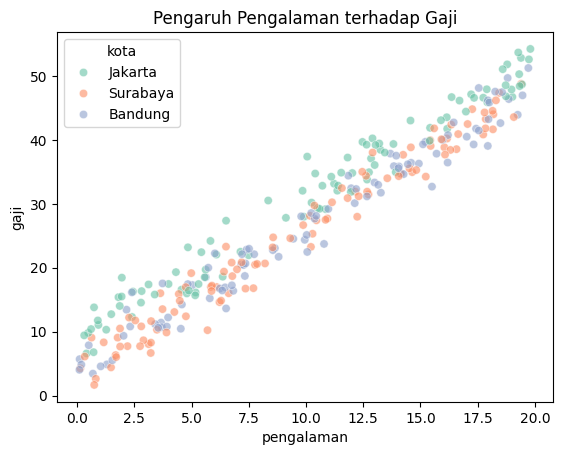

In [2]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
# Generate dataset sintetis
np.random.seed(42); n = 300
pengalaman = np.random.uniform(0, 20, n)
edu = np.random.choice([0, 1, 2], n) # SMA=0, D3=1, S1=2
kota = np.random.choice(['Jakarta','Surabaya','Bandung'], n)
gaji = (3.0 + 2.2*pengalaman + 1.5*edu
 + np.where(kota=='Jakarta', 4.0, 0)
 + np.random.normal(0, 2, n))
df = pd.DataFrame({'pengalaman':pengalaman, 'edu':edu,
 'kota':kota, 'gaji':gaji})
# EDA singkat
print('Shape:', df.shape)
print(df.describe().round(2))
# Scatter: pengalaman vs gaji
sns.scatterplot(data=df, x='pengalaman', y='gaji',
 hue='kota', palette='Set2', alpha=0.6)
plt.title('Pengaruh Pengalaman terhadap Gaji')

2. Preprocessing

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
# One-Hot Encoding kolom 'kota'
df = pd.get_dummies(df, columns=['kota'],
 drop_first=True, dtype=int)
print('Kolom setelah encoding:', df.columns.tolist())
# Pisahkan fitur dan target
X = df.drop('gaji', axis=1)
y = df['gaji']
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
 X, y, test_size=0.2, random_state=42)
print(f'Train: {X_train.shape[0]} baris, Test: {X_test.shape[0]} baris')
# StandardScaler — fit pada training set saja
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

Kolom setelah encoding: ['pengalaman', 'edu', 'gaji', 'kota_Jakarta', 'kota_Surabaya']
Train: 240 baris, Test: 60 baris


3. Latih Model & Tampilkan Koefisien

In [4]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train_s, y_train)
# Tampilkan koefisien
print(f'β₀ (intercept): {model.intercept_:.3f}')
print()
coef_df = pd.DataFrame({
 'Fitur' : X.columns,
 'Koefisien' : model.coef_.round(3)
}).sort_values('Koefisien', ascending=False)
print(coef_df.to_string(index=False))
# Interpretasi: fitur mana yang paling berpengaruh?
# Koefisien positif → gaji naik
# Koefisien negatif → gaji turun

β₀ (intercept): 27.514

        Fitur  Koefisien
   pengalaman     13.042
 kota_Jakarta      1.837
          edu      1.188
kota_Surabaya     -0.292


4. Evaluasi Model

In [6]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np # Import numpy for sqrt

y_pred = model.predict(X_test_s)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print('=== Metrik Evaluasi ===')
print(f'MAE = {mae:.3f} juta rupiah')
print(f'RMSE = {rmse:.3f} juta rupiah')
print(f'R² = {r2:.4f} ({r2*100:.1f}% variasi dijelaskan)')
print(f'Selisih RMSE-MAE = {rmse-mae:.3f}')
# Interpretasikan dalam Markdown sel berikutnya:
# - Berapa rata-rata kesalahan prediksi dalam rupiah?
# - Apakah R² cukup baik untuk kasus ini?
# - Apakah ada indikasi outlier?

=== Metrik Evaluasi ===
MAE = 1.649 juta rupiah
RMSE = 2.123 juta rupiah
R² = 0.9740 (97.4% variasi dijelaskan)
Selisih RMSE-MAE = 0.474


5. Visualisasi & Interpretasi

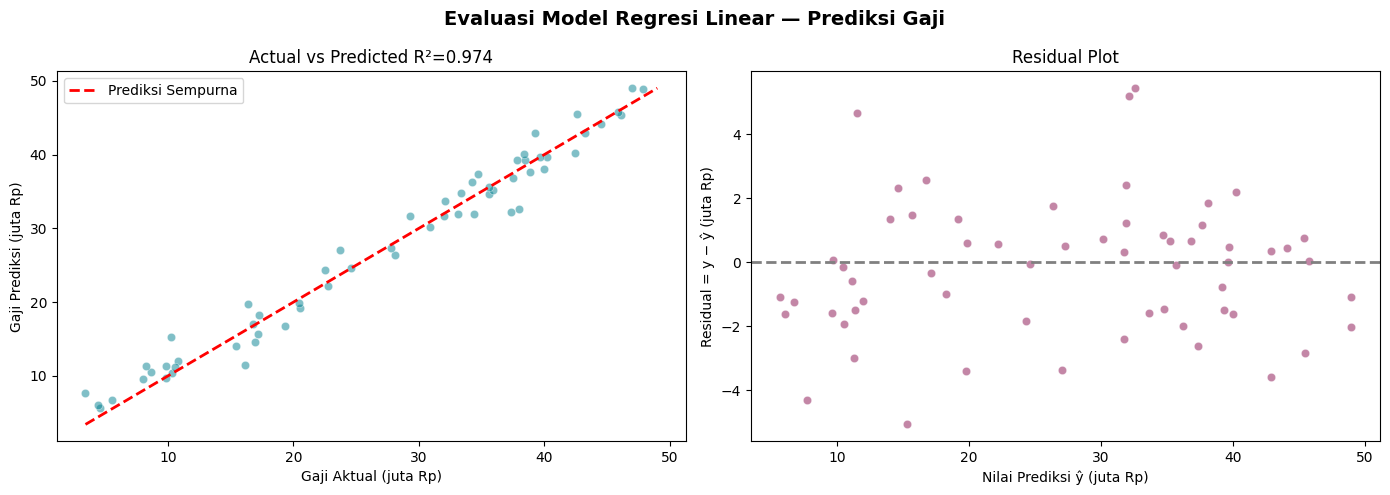

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Plot 1: Actual vs Predicted
axes[0].scatter(y_test, y_pred, alpha=0.5,
 color='#028090', edgecolors='white', lw=0.5)
lims = [min(y_test.min(), y_pred.min()),
 max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, 'r--', lw=2,
 label='Prediksi Sempurna')
axes[0].set_xlabel('Gaji Aktual (juta Rp)')
axes[0].set_ylabel('Gaji Prediksi (juta Rp)')
axes[0].set_title(f'Actual vs Predicted R²={r2:.3f}')
axes[0].legend()
# Plot 2: Residual Plot
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.5,
 color='#880E4F', edgecolors='white', lw=0.5)
axes[1].axhline(0, color='gray', linestyle='--', lw=2)
axes[1].set_xlabel('Nilai Prediksi ŷ (juta Rp)')
axes[1].set_ylabel('Residual = y − ŷ (juta Rp)')
axes[1].set_title('Residual Plot')
plt.suptitle('Evaluasi Model Regresi Linear — Prediksi Gaji',
 fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('evaluasi_regresi.png', dpi=150, bbox_inches='tight')
plt.show()

**Kesimpulan Analisis Regresi Linear Prediksi Gaji**

---


Analisis ini melibatkan pembangunan model regresi linear untuk memprediksi gaji berdasarkan pengalaman, tingkat pendidikan, dan lokasi kota. Berikut adalah ringkasan hasilnya:


**Eksplorasi Data**:

---


Data sintetis menunjukkan hubungan positif antara

pengalaman dan gaji, dengan variasi gaji juga dipengaruhi oleh kota dan pendidikan.


**Pra-pemrosesan:**

---


Fitur kategori 'kota' di-encode menggunakan One-Hot Encoding, dan data diskalakan serta dibagi menjadi set pelatihan dan pengujian untuk persiapan model.

**Model & Koefisien**:

---


 Model Regresi Linear menunjukkan 'pengalaman' sebagai prediktor terkuat (koefisien = 13.042), diikuti 'kota_Jakarta' (1.837), dan 'pendidikan' (1.188). Ini berarti pengalaman dan berada di Jakarta secara signifikan meningkatkan prediksi gaji, sementara pendidikan juga berkontribusi positif.

**Evaluasi Model**:

---


Model menunjukkan kinerja yang sangat baik:

MAE: 1.649 juta rupiah (rata-rata kesalahan prediksi).
RMSE: 2.123 juta rupiah (kesalahan prediksi, sensitif terhadap outlier).
R²: 0.9740 (97.4% variasi gaji dapat dijelaskan oleh model). Angka R² yang tinggi ini menandakan model memiliki kekuatan prediktif yang sangat kuat.
Visualisasi: Plot Actual vs Predicted menunjukkan keselarasan yang tinggi antara nilai aktual dan prediksi. Plot Residual menunjukkan distribusi error yang acak di sekitar nol, mengindikasikan bahwa asumsi model terpenuhi dan tidak ada bias sistematis.

**Kesimpulan Umum:**

---


Model regresi linear yang dikembangkan sangat efektif dalam memprediksi gaji berdasarkan faktor-faktor yang dipertimbangkan, dengan tingkat akurasi yang tinggi dan kesalahan prediksi yang minimal. Hasil ini valid untuk dataset yang digunakan.